In [1]:
import pandas as pd
import requests 
import json
import os
#import networkx as nx

import matplotlib.pyplot as plt
#from wordcloud import WordCloud

from collections import defaultdict
import spacy
#import Functions as fn
#import seaborn as sns
import numpy as np  
#from fitter import Fitter
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

In [2]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
nlp = spacy.load("en_core_sci_sm") 

/opt/conda/lib/python3.11/site-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


In [4]:
pwd

'/home/eidf128/eidf128/shared/export/juliana/export/juliana'

In [5]:
home_dir = '/home/eidf128/eidf128/shared/export/juliana/export/juliana'

### Functions

##### Cleaning

In [6]:
def remove_stop_words(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))
    filtered = [w for w in tokens if w.lower() not in stop_words and w.isalpha()]

    return filtered

In [7]:
def remove_special_characters(text):
    """
    This function removes special characters from the text.
    :param text: text
    :return: text without special characters
    """
    cleaned_string = re.sub(r'[?|$|.|!|@|#|%|^|&|*|(|)|-|_|+|=|;|:|,|<|>|/|{|}|[|]|~|`|\'|\"|\\]',r'', text)

    return cleaned_string

In [8]:
def clean_text(text):
    if pd.isna(text) or str(text).strip() == "":
        return ""
    text = remove_special_characters(str(text)) or ""
    
    return remove_stop_words(text)

##### NLP

In [9]:
# It lemmizes a text
def lemmatizer(phrase):
    """
    This function lemmatizes a text.
    :param phrase: text

    :return: the lemmatized text
    """
    doc = nlp(phrase)
    lemmatized_tokens = [token.lemma_ for token in doc]
    lemmatized_text = ' '.join(lemmatized_tokens)
    
    return lemmatized_text

In [10]:
# It extracts the entities from a text
def entities_recognition(phrase):
    """
    This function extracts the entities from a text.
    :param phrase: text
    :return: the entities extracted from the text
    """
    entities = []
    doc_phrase = nlp(phrase)
    entities = list(doc_phrase.ents)
    
    return entities

In [10]:
def entities_concatenated(list_dfs,title):
    """
    This function concatenates the entities extracted from a list columns names given as parameter of a list of dataframes.
    :param list_dfs: list of dataframes
    :param title: new column name

    :return: the list of dataframes with the entities concatenated in a new column
    """
    count = 0
    while count < len(list_dfs):
        wk_df = list_dfs[count]
        list1 = wk_df["dc.description.abstract_entities_recognised_after_lemmatizer_and_splitting"]
        
        concatenated_list = list1 
        wk_df[title] = concatenated_list

        count += 1
        
    return list_dfs

In [13]:
# It counts the number of words in a phrase
def count_words(phrase):
    """
    This function counts the number of words in a phrase.
    :param phrase: text

    :return: the number of words in the phrase
    """
    lenght = 0
    if len(phrase) > 1 and phrase.isspace() == True:
        lenght = 1
    
    else:
        words = phrase.split()
        lenght = len(words)
    
    return lenght

In [14]:
# It counts the number of characters in a phrase
def count_characters(phrase):
    """
    This function counts the number of characters in a phrase.
    :param phrase: text

    :return: the number of characters in the phrase
    """
    lenght = 0
    if len(phrase) < 1:
        lenght = 0
    else:
        lenght = len(phrase)
        
    return lenght

In [15]:
def first_non_null(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else pd.NA

In [16]:
def join_unique_non_null(s, sep=" | "):
    s = s.dropna().astype(str)
    s = s[s.str.strip().ne("")]           # drop empty strings
    s = pd.unique(s)                      # keep unique (preserve order)
    return sep.join(s) if len(s) else pd.NA

In [17]:
def to_text(x):
    # missing
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return ""
    # already a string
    if isinstance(x, str):
        return x
    # list/tuple/set/np array of tokens
    if isinstance(x, (list, tuple, set, np.ndarray)):
        return " ".join(map(str, x))
    # fallback: convert whatever it is to string
    return str(x)

## BioDare2

In [18]:
data_dir = '/home/eidf128/eidf128/shared/export/juliana/export/juliana/BioDare_metadata_20250722'

In [19]:
os.chdir(data_dir)

In [20]:
files = [f for f in os.listdir(data_dir) if f.endswith('.json')]
len(files)

20471

In [21]:
df_biodare2 = pd.DataFrame()
dfs = []
for file in files:
    temp_df = pd.read_json(file)
    dfs.append(temp_df)
    
df_biodare2 = pd.concat(dfs, ignore_index=True, sort=False)

In [22]:
df_biodare2

,id,versionId,generalDesc,contributionDesc,experimentalDetails,characteristic,bioDescription,bioSummary,species,dataCategory,provenance
0,20080,56.0.2,Testing rhythmicity in organoids,NaN,NaN,NaN,NaN,NaN,Homo sapiens,EXPR_REPORTER,NaN
1,20080,56.0.2,Validation of circadian rhythmicity in organoi...,NaN,NaN,NaN,NaN,NaN,Homo sapiens,EXPR_REPORTER,NaN
2,20080,56.0.2,NaN,NaN,NaN,NaN,NaN,NaN,Homo sapiens,EXPR_REPORTER,NaN
3,20080,56.0.2,Automatically published by BioDare2 system on ...,NaN,NaN,NaN,NaN,NaN,Homo sapiens,EXPR_REPORTER,NaN
4,20080,56.0.2,NaN,"[{'id': 2734, 'login': 'sungkook.chun', 'first...",NaN,NaN,NaN,NaN,Homo sapiens,EXPR_REPORTER,NaN
...,...,...,...,...,...,...,...,...,...,...,...
798224,30684,2.0.2,NaN,NaN,NaN,NaN,NaN,[],Homo sapiens,EXPR_REPORTER,NaN
798225,30684,2.0.2,NaN,NaN,NaN,NaN,NaN,NaN,Homo sapiens,EXPR_REPORTER,"[2024, 12, 19, 11, 19, 24, 801612438]"
798226,30684,2.0.2,NaN,NaN,NaN,NaN,NaN,NaN,Homo sapiens,EXPR_REPORTER,Loïc Metz
798227,30684,2.0.2,NaN,NaN,NaN,NaN,NaN,NaN,Homo sapiens,EXPR_REPORTER,"[2024, 12, 19, 11, 23, 16, 404619841]"


In [23]:
df_biodare2.columns

Index(['id', 'versionId', 'generalDesc', 'contributionDesc',
       'experimentalDetails', 'characteristic', 'bioDescription', 'bioSummary',
       'species', 'dataCategory', 'provenance'],
      dtype='str')

In [24]:
df_biodare2_collapsed = (
    df_biodare2.groupby("id", as_index=False)
      .agg({
          "versionId": first_non_null,
          ""
          "generalDesc": join_unique_non_null,   # combine all descriptions
          "contributionDesc": first_non_null,
          "experimentalDetails": first_non_null,
          "characteristic": first_non_null,
          "bioDescription": first_non_null,
          "bioSummary": first_non_null,
          "species": first_non_null,
          "dataCategory": first_non_null,
          "provenance": first_non_null,
      })
)

df_biodare2_clean = pd.DataFrame(df_biodare2_collapsed)

In [28]:
type(df_biodare2_clean)

pandas.DataFrame

In [29]:
df_biodare2_clean

,id,versionId,generalDesc,contributionDesc,experimentalDetails,characteristic,bioDescription,bioSummary,species,dataCategory,provenance
0,1153,2.0.2,Controls | Global Search | null\nGrowth condit...,"[{'id': None, 'login': None, 'firstName': 'Fel...","{'technique': 'Luciferase luminescence', 'equi...",False,[],[],Neurospora crassa,GEN_IMAGING,"[2014, 5, 5, 12, 40]"
1,2842,2.0.2,TiMet WP1.1 qRT-PCR elf3 LD | TiMet focuses on...,"[{'id': None, 'login': None, 'firstName': 'Ann...","{'technique': 'RT-PCR', 'equipment': 'PerkinEl...",False,[],[],Arabidopsis thaliana,TRANSCRIPT,"[2015, 2, 22, 18, 47, 37]"
2,3492,3.0.3,Q-PCR LD (12:12) 17C LHY | Experiment to repar...,"[{'id': None, 'login': None, 'firstName': 'Aur...","{'technique': 'qRT-PCR', 'equipment': 'Robot +...",False,[],[],Arabidopsis thaliana,TRANSCRIPT,"[2015, 9, 4, 1, 21, 5]"
3,3638,4.0.3,cca1 lhy Long #1 CCA1 marker | Test for period...,"[{'id': None, 'login': None, 'firstName': 'Vic...","{'technique': 'Luciferase luminescence', 'equi...",False,[],[],Arabidopsis thaliana,EXPR_REPORTER,"[2015, 10, 27, 20, 2, 45]"
4,3647,2.0.2,cca1 lhy Long #1 CAB2 marker | Test for period...,"[{'id': None, 'login': None, 'firstName': 'Vic...","{'technique': 'Luciferase luminescence', 'equi...",False,[],[],Arabidopsis thaliana,EXPR_REPORTER,"[2015, 10, 29, 0, 0, 32]"
...,...,...,...,...,...,...,...,...,...,...,...
20466,13790739219191,2.0.3,"Niwa et al. (2007); GI, FKF1, CDF1, CO, FT mRN...","[{'id': None, 'login': None, 'firstName': 'Niw...","{'technique': 'RT-PCR', 'equipment': None, 'de...",False,[],[],Arabidopsis thaliana,TRANSCRIPT,"[2013, 9, 13, 13, 5, 21]"
20467,13790860334747,2.0.3,AT0053: 4x3:21-LL | photoperiod alteration st...,"[{'id': None, 'login': None, 'firstName': 'Adr...","{'technique': 'Luciferase luminescence', 'equi...",False,[],[],Arabidopsis thaliana,EXPR_REPORTER,"[2013, 9, 13, 16, 27, 13]"
20468,13945617808900,5.0.4,Analysis of Control Strains Neurospora crassa ...,"[{'id': None, 'login': None, 'firstName': 'Fel...","{'technique': 'Luciferase luminescence', 'equi...",False,[],[],Neurospora crassa,GEN_IMAGING,"[2014, 3, 11, 18, 16, 20]"
20469,13982027442235,4.0.5,030810H3 SD-LD | Re-entrainment dynamics durin...,"[{'id': None, 'login': None, 'firstName': 'Sar...","{'technique': 'Luciferase luminescence', 'equi...",False,[],[],Arabidopsis thaliana,EXPR_REPORTER,"[2014, 4, 22, 22, 39, 4]"


In [27]:
df_biodare2_clean['generalDesc'][1]

'TiMet WP1.1 qRT-PCR elf3 LD | TiMet focuses on an important and general biological problem – how  are plant metabolism \nand growth regulated and orchestrated in a daily-changing environment? | WT and elf3-4 mutants, in biological duplicates, diurnal light, harvest every 2 hours\nNumbers are in transcript copy per cell, obtained assuming 1 g FW contains 25000000 cells. | The elf3 mutant was harvested at 13 day not at 21 as the rest due to its early flowering phenotype. This experiment is partenr to "TiMet WP1.1 qRT-PCR LD to LL and LD"\nGrowth conditions:\nLD 20/18C; diurn. 20.0C:18.0C 12:00:12:00 W: LD 12:00:12:00\nExperimental conditions:\nLD 20/18C; diurn. 20.0C:18.0C 12:00:12:00 W: LD 12:00:12:00'

#### Cleaning

In [28]:
#Replace None with nothing
df_biodare2_clean.replace(to_replace=[None], value="", inplace=True)

,id,versionId,generalDesc,contributionDesc,experimentalDetails,characteristic,bioDescription,bioSummary,species,dataCategory,provenance
0,1153,2.0.2,Controls | Global Search | null\nGrowth condit...,"[{'id': None, 'login': None, 'firstName': 'Fel...","{'technique': 'Luciferase luminescence', 'equi...",False,[],[],Neurospora crassa,GEN_IMAGING,"[2014, 5, 5, 12, 40]"
1,2842,2.0.2,TiMet WP1.1 qRT-PCR elf3 LD | TiMet focuses on...,"[{'id': None, 'login': None, 'firstName': 'Ann...","{'technique': 'RT-PCR', 'equipment': 'PerkinEl...",False,[],[],Arabidopsis thaliana,TRANSCRIPT,"[2015, 2, 22, 18, 47, 37]"
2,3492,3.0.3,Q-PCR LD (12:12) 17C LHY | Experiment to repar...,"[{'id': None, 'login': None, 'firstName': 'Aur...","{'technique': 'qRT-PCR', 'equipment': 'Robot +...",False,[],[],Arabidopsis thaliana,TRANSCRIPT,"[2015, 9, 4, 1, 21, 5]"
3,3638,4.0.3,cca1 lhy Long #1 CCA1 marker | Test for period...,"[{'id': None, 'login': None, 'firstName': 'Vic...","{'technique': 'Luciferase luminescence', 'equi...",False,[],[],Arabidopsis thaliana,EXPR_REPORTER,"[2015, 10, 27, 20, 2, 45]"
4,3647,2.0.2,cca1 lhy Long #1 CAB2 marker | Test for period...,"[{'id': None, 'login': None, 'firstName': 'Vic...","{'technique': 'Luciferase luminescence', 'equi...",False,[],[],Arabidopsis thaliana,EXPR_REPORTER,"[2015, 10, 29, 0, 0, 32]"
...,...,...,...,...,...,...,...,...,...,...,...
20466,13790739219191,2.0.3,"Niwa et al. (2007); GI, FKF1, CDF1, CO, FT mRN...","[{'id': None, 'login': None, 'firstName': 'Niw...","{'technique': 'RT-PCR', 'equipment': None, 'de...",False,[],[],Arabidopsis thaliana,TRANSCRIPT,"[2013, 9, 13, 13, 5, 21]"
20467,13790860334747,2.0.3,AT0053: 4x3:21-LL | photoperiod alteration st...,"[{'id': None, 'login': None, 'firstName': 'Adr...","{'technique': 'Luciferase luminescence', 'equi...",False,[],[],Arabidopsis thaliana,EXPR_REPORTER,"[2013, 9, 13, 16, 27, 13]"
20468,13945617808900,5.0.4,Analysis of Control Strains Neurospora crassa ...,"[{'id': None, 'login': None, 'firstName': 'Fel...","{'technique': 'Luciferase luminescence', 'equi...",False,[],[],Neurospora crassa,GEN_IMAGING,"[2014, 3, 11, 18, 16, 20]"
20469,13982027442235,4.0.5,030810H3 SD-LD | Re-entrainment dynamics durin...,"[{'id': None, 'login': None, 'firstName': 'Sar...","{'technique': 'Luciferase luminescence', 'equi...",False,[],[],Arabidopsis thaliana,EXPR_REPORTER,"[2014, 4, 22, 22, 39, 4]"


In [29]:
# Everything to lowercase

obj_cols = df_biodare2_clean.select_dtypes(include=["object", "string"]).columns
df_biodare2_clean[obj_cols] = df_biodare2_clean[obj_cols].astype("string").apply(lambda s: s.str.lower())

##### Separating the columns

In [30]:
df_biodare2_clean["Name"] = (
    df_biodare2_clean["generalDesc"]
    .str.split('|', expand = False)
    .str[0]
    .fillna("")
)

In [31]:
df_biodare2_clean["Purpose"] = (
    df_biodare2_clean["generalDesc"]
    .str.split('|', expand = False)
    .str[1]
    .fillna("")
)

In [32]:
df_biodare2_clean["Description"] = (
    df_biodare2_clean["generalDesc"]
    .str.split('|', expand = False)
    .str[2]
    .fillna("")
)

In [33]:
df_biodare2_clean["Comments"] = (
    df_biodare2_clean["generalDesc"]
    .str.split('|', expand = False)
    .str[3]
    .fillna("")
)

In [34]:
df_biodare2_clean

,id,versionId,generalDesc,contributionDesc,experimentalDetails,characteristic,bioDescription,bioSummary,species,dataCategory,provenance,Name,Purpose,Description,Comments
0,1153,2.0.2,controls | global search | null\ngrowth condit...,"[{'id': none, 'login': none, 'firstname': 'fel...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],neurospora crassa,gen_imaging,"[2014, 5, 5, 12, 40]",controls,global search,null\ngrowth conditions:\nll24; const. 25.0c ...,
1,2842,2.0.2,timet wp1.1 qrt-pcr elf3 ld | timet focuses on...,"[{'id': none, 'login': none, 'firstname': 'ann...","{'technique': 'rt-pcr', 'equipment': 'perkinel...",false,[],[],arabidopsis thaliana,transcript,"[2015, 2, 22, 18, 47, 37]",timet wp1.1 qrt-pcr elf3 ld,timet focuses on an important and general bio...,"wt and elf3-4 mutants, in biological duplicat...",the elf3 mutant was harvested at 13 day not a...
2,3492,3.0.3,q-pcr ld (12:12) 17c lhy | experiment to repar...,"[{'id': none, 'login': none, 'firstname': 'aur...","{'technique': 'qrt-pcr', 'equipment': 'robot +...",false,[],[],arabidopsis thaliana,transcript,"[2015, 9, 4, 1, 21, 5]",q-pcr ld (12:12) 17c lhy,experiment to reparameterize the clock model ...,literature data from: 'temp'\n\t by: auror...,24h sample lost for several genotypes. \ncura...
3,3638,4.0.3,cca1 lhy long #1 cca1 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,"[2015, 10, 27, 20, 2, 45]",cca1 lhy long #1 cca1 marker,test for period changes during seedlling grow...,"if periods change during development, then ou...",data collection by victoria hibberd ca. septe...
4,3647,2.0.2,cca1 lhy long #1 cab2 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,"[2015, 10, 29, 0, 0, 32]",cca1 lhy long #1 cab2 marker,test for period changes during seedlling grow...,"if periods change during development, then ou...",data collection by victoria hibberd ca. septe...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20466,13790739219191,2.0.3,"niwa et al. (2007); gi, fkf1, cdf1, co, ft mrn...","[{'id': none, 'login': none, 'firstname': 'niw...","{'technique': 'rt-pcr', 'equipment': none, 'de...",false,[],[],arabidopsis thaliana,transcript,"[2013, 9, 13, 13, 5, 21]","niwa et al. (2007); gi, fkf1, cdf1, co, ft mrn...","in arabidopsis thaliana, the flowering time i...",null\ngrowth conditions:\nniwa2007; const. 22...,
20467,13790860334747,2.0.3,at0053: 4x3:21-ll | photoperiod alteration st...,"[{'id': none, 'login': none, 'firstname': 'adr...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,"[2013, 9, 13, 16, 27, 13]",at0053: 4x3:21-ll,photoperiod alteration study,luc imaging under 3:21 cycles then constant l...,imaging started 23/01/07. \nfungal infection ...
20468,13945617808900,5.0.4,analysis of control strains neurospora crassa ...,"[{'id': none, 'login': none, 'firstname': 'fel...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],neurospora crassa,gen_imaging,"[2014, 3, 11, 18, 16, 20]",analysis of control strains neurospora crassa,compare different siblings of the parental/co...,null\ngrowth conditions:\nll condition; const...,
20469,13982027442235,4.0.5,030810h3 sd-ld | re-entrainment dynamics durin...,"[{'id': none, 'login': none, 'firstname': 'sar...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,"[2014, 4, 22, 22, 39, 4]",030810h3 sd-ld,re-entrainment dynamics during transition bet...,plants entrained in 8l:16d (120umol m-2s-1) f...,partner experiment : 030810h3 ld-ld\ngrowth c...


#### Stats

In [35]:
df_biodare2_clean.columns

Index(['id', 'versionId', 'generalDesc', 'contributionDesc',
       'experimentalDetails', 'characteristic', 'bioDescription', 'bioSummary',
       'species', 'dataCategory', 'provenance', 'Name', 'Purpose',
       'Description', 'Comments'],
      dtype='str')

In [36]:
list_header_stats = ['Name','Purpose','Description','Comments']

#### Cleaning

In [37]:
for header in list_header_stats:
    df_biodare2_clean[f"{header}_clean"] = pd.Series(index=df_biodare2_clean.index, dtype="object")

In [38]:
df2 = df_biodare2_clean.reset_index(drop=True)

for i, row in df2.iterrows():
    print(f"Processing row {i+1}/{len(df2)}")
    for header in list_header_stats:
        value_to_clean = row[header]
        if pd.notna(value_to_clean) and value_to_clean != "":
            title = f"{header}_clean"
            df2.at[i, title]= clean_text(value_to_clean)

Processing row 1/20471
Processing row 2/20471
Processing row 3/20471
Processing row 4/20471
Processing row 5/20471
Processing row 6/20471
Processing row 7/20471
Processing row 8/20471
Processing row 9/20471
Processing row 10/20471
Processing row 11/20471
Processing row 12/20471
Processing row 13/20471
Processing row 14/20471
Processing row 15/20471
Processing row 16/20471
Processing row 17/20471
Processing row 18/20471
Processing row 19/20471
Processing row 20/20471
Processing row 21/20471
Processing row 22/20471
Processing row 23/20471
Processing row 24/20471
Processing row 25/20471
Processing row 26/20471
Processing row 27/20471
Processing row 28/20471
Processing row 29/20471
Processing row 30/20471
Processing row 31/20471
Processing row 32/20471
Processing row 33/20471
Processing row 34/20471
Processing row 35/20471
Processing row 36/20471
Processing row 37/20471
Processing row 38/20471
Processing row 39/20471
Processing row 40/20471
Processing row 41/20471
Processing row 42/20471
P

In [39]:
df_biodare2_clean = df2

In [40]:
# Words count
for idx, row in df_biodare2_clean.iterrows():
    for header in list_header_stats: 
        str_to_count = df_biodare2_clean.at[idx, header]
        count_number = count_words(str_to_count)
        title = f"{header}_words_count"

        df_biodare2_clean.at[idx, title] = count_number
    

In [41]:
df_biodare2_clean

,id,versionId,generalDesc,contributionDesc,experimentalDetails,characteristic,bioDescription,bioSummary,species,dataCategory,...,Description,Comments,Name_clean,Purpose_clean,Description_clean,Comments_clean,Name_words_count,Purpose_words_count,Description_words_count,Comments_words_count
0,1153,2.0.2,controls | global search | null\ngrowth condit...,"[{'id': none, 'login': none, 'firstname': 'fel...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],neurospora crassa,gen_imaging,...,null\ngrowth conditions:\nll24; const. 25.0c ...,,[controls],"[global, search]","[null, growth, conditions, const, w, experimen...",NaN,1.0,2.0,16.0,0.0
1,2842,2.0.2,timet wp1.1 qrt-pcr elf3 ld | timet focuses on...,"[{'id': none, 'login': none, 'firstname': 'ann...","{'technique': 'rt-pcr', 'equipment': 'perkinel...",false,[],[],arabidopsis thaliana,transcript,...,"wt and elf3-4 mutants, in biological duplicat...",the elf3 mutant was harvested at 13 day not a...,"[timet, ld]","[timet, focuses, important, general, biologica...","[wt, mutants, biological, duplicates, diurnal,...","[mutant, harvested, day, rest, due, early, flo...",5.0,23.0,28.0,53.0
2,3492,3.0.3,q-pcr ld (12:12) 17c lhy | experiment to repar...,"[{'id': none, 'login': none, 'firstname': 'aur...","{'technique': 'qrt-pcr', 'equipment': 'robot +...",false,[],[],arabidopsis thaliana,transcript,...,literature data from: 'temp'\n\t by: auror...,24h sample lost for several genotypes. \ncura...,"[ld, lhy]","[experiment, reparameterize, clock, model, wit...","[literature, data, temp, aurora, seedlings, en...","[sample, lost, several, genotypes, curated, an...",5.0,9.0,43.0,75.0
3,3638,4.0.3,cca1 lhy long #1 cca1 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,"if periods change during development, then ou...",data collection by victoria hibberd ca. septe...,"[lhy, long, marker]","[test, period, changes, seedlling, growth, top...","[periods, change, development, genetic, screen...","[data, collection, victoria, hibberd, ca, sept...",6.0,17.0,73.0,37.0
4,3647,2.0.2,cca1 lhy long #1 cab2 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,"if periods change during development, then ou...",data collection by victoria hibberd ca. septe...,"[lhy, long, marker]","[test, period, changes, seedlling, growth, top...","[periods, change, development, genetic, screen...","[data, collection, victoria, hibberd, ca, sept...",6.0,17.0,73.0,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20466,13790739219191,2.0.3,"niwa et al. (2007); gi, fkf1, cdf1, co, ft mrn...","[{'id': none, 'login': none, 'firstname': 'niw...","{'technique': 'rt-pcr', 'equipment': none, 'de...",false,[],[],arabidopsis thaliana,transcript,...,null\ngrowth conditions:\nniwa2007; const. 22...,,"[niwa, et, al, gi, co, ft, mrna, wt]","[arabidopsis, thaliana, flowering, time, regul...","[null, growth, conditions, const, w, ld, exper...",NaN,14.0,244.0,17.0,0.0
20467,13790860334747,2.0.3,at0053: 4x3:21-ll | photoperiod alteration st...,"[{'id': none, 'login': none, 'firstname': 'adr...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,luc imaging under 3:21 cycles then constant l...,imaging started 23/01/07. \nfungal infection ...,[],"[photoperiod, alteration, study]","[luc, imaging, cycles, constant, light, replic...","[imaging, started, fungal, infection, gi, lhy,...",2.0,3.0,16.0,64.0
20468,13945617808900,5.0.4,analysis of control strains neurospora crassa ...,"[{'id': none, 'login': none, 'firstname': 'fel...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],neurospora crassa,gen_imaging,...,null\ngrowth conditions:\nll condition; const...,,"[analysis, 

In [42]:
test = df2.at[0,"Purpose_clean"]
len(test)

2

In [43]:
list_header_stats = ['Name_clean','Purpose_clean','Description_clean','Comments_clean']

In [44]:
for header in list_header_stats:
    df_biodare2_clean[f"{header}_word_count"] = pd.Series(index=df_biodare2_clean.index, dtype="object")

In [45]:
df_biodare2_clean["Name_clean_word_count"] = (
    df_biodare2_clean["Name_clean"].apply(lambda x: len(x) if isinstance(x, list) else 0)
)

In [52]:
df_biodare2_clean["Purpose_clean_word_count"] = (
    df_biodare2_clean["Purpose_clean"].apply(lambda x: len(x) if isinstance(x, list) else 0)
)

In [53]:
df_biodare2_clean["Description_clean_word_count"] = (
    df_biodare2_clean["Description_clean"].apply(lambda x: len(x) if isinstance(x, list) else 0)
)

In [54]:
df_biodare2_clean["Comments_clean_word_count"] = (
    df_biodare2_clean["Comments_clean"].apply(lambda x: len(x) if isinstance(x, list) else 0)
)

In [51]:
df_biodare2_clean.at[2,"Name_clean"]

['ld', 'lhy']

In [55]:
df_biodare2_clean

,id,versionId,generalDesc,contributionDesc,experimentalDetails,characteristic,bioDescription,bioSummary,species,dataCategory,...,Description_clean,Comments_clean,Name_words_count,Purpose_words_count,Description_words_count,Comments_words_count,Name_clean_word_count,Purpose_clean_word_count,Description_clean_word_count,Comments_clean_word_count
0,1153,2.0.2,controls | global search | null\ngrowth condit...,"[{'id': none, 'login': none, 'firstname': 'fel...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],neurospora crassa,gen_imaging,...,"[null, growth, conditions, const, w, experimen...",NaN,1.0,2.0,16.0,0.0,1,2,12,0
1,2842,2.0.2,timet wp1.1 qrt-pcr elf3 ld | timet focuses on...,"[{'id': none, 'login': none, 'firstname': 'ann...","{'technique': 'rt-pcr', 'equipment': 'perkinel...",false,[],[],arabidopsis thaliana,transcript,...,"[wt, mutants, biological, duplicates, diurnal,...","[mutant, harvested, day, rest, due, early, flo...",5.0,23.0,28.0,53.0,2,12,20,25
2,3492,3.0.3,q-pcr ld (12:12) 17c lhy | experiment to repar...,"[{'id': none, 'login': none, 'firstname': 'aur...","{'technique': 'qrt-pcr', 'equipment': 'robot +...",false,[],[],arabidopsis thaliana,transcript,...,"[literature, data, temp, aurora, seedlings, en...","[sample, lost, several, genotypes, curated, an...",5.0,9.0,43.0,75.0,2,7,17,45
3,3638,4.0.3,cca1 lhy long #1 cca1 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,"[periods, change, development, genetic, screen...","[data, collection, victoria, hibberd, ca, sept...",6.0,17.0,73.0,37.0,3,11,42,24
4,3647,2.0.2,cca1 lhy long #1 cab2 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,"[periods, change, development, genetic, screen...","[data, collection, victoria, hibberd, ca, sept...",6.0,17.0,73.0,37.0,3,11,42,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20466,13790739219191,2.0.3,"niwa et al. (2007); gi, fkf1, cdf1, co, ft mrn...","[{'id': none, 'login': none, 'firstname': 'niw...","{'technique': 'rt-pcr', 'equipment': none, 'de...",false,[],[],arabidopsis thaliana,transcript,...,"[null, growth, conditions, const, w, ld, exper...",NaN,14.0,244.0,17.0,0.0,8,130,11,0
20467,13790860334747,2.0.3,at0053: 4x3:21-ll | photoperiod alteration st...,"[{'id': none, 'login': none, 'firstname': 'adr...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,"[luc, imaging, cycles, constant, light, replic...","[imaging, started, fungal, infection, gi, lhy,...",2.0,3.0,16.0,64.0,0,3,8,38
20468,13945617808900,5.0.4,analysis of control strains neurospora crassa ...,"[{'id': none, 'login': none, 'firstname': 'fel...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],neurospora crassa,gen_imaging,...,"[null, growth, conditions, condition, const, w...",NaN,6.0,20.0,17.0,0.0,5,13,13,0
20469,13982027442235,4.0.5,030810h3 sd-ld | re-entrainment dynamics durin...,"[{'id': none, 'login': none, 'firstname': 'sar...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,"[plants, entrained, days, experimental, condit...","[partner, experiment, growth, conditions, cons...",2.0,24.0,22.0,25.0,0,15,10,13


In [56]:
# Creating the empty columns for lemma text and entities 
for header in list_header_stats:
    df_biodare2_clean[f"{header}_lemmatize"] = pd.Series(index=df_biodare2_clean.index, dtype="object")
    df_biodare2_clean[f"{header}_entities"]  = pd.Series(index=df_biodare2_clean.index, dtype="object")

In [57]:
df_biodare2_clean

,id,versionId,generalDesc,contributionDesc,experimentalDetails,characteristic,bioDescription,bioSummary,species,dataCategory,...,Description_clean_word_count,Comments_clean_word_count,Name_clean_lemmatize,Name_clean_entities,Purpose_clean_lemmatize,Purpose_clean_entities,Description_clean_lemmatize,Description_clean_entities,Comments_clean_lemmatize,Comments_clean_entities
0,1153,2.0.2,controls | global search | null\ngrowth condit...,"[{'id': none, 'login': none, 'firstname': 'fel...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],neurospora crassa,gen_imaging,...,12,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2842,2.0.2,timet wp1.1 qrt-pcr elf3 ld | timet focuses on...,"[{'id': none, 'login': none, 'firstname': 'ann...","{'technique': 'rt-pcr', 'equipment': 'perkinel...",false,[],[],arabidopsis thaliana,transcript,...,20,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3492,3.0.3,q-pcr ld (12:12) 17c lhy | experiment to repar...,"[{'id': none, 'login': none, 'firstname': 'aur...","{'technique': 'qrt-pcr', 'equipment': 'robot +...",false,[],[],arabidopsis thaliana,transcript,...,17,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3638,4.0.3,cca1 lhy long #1 cca1 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,42,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3647,2.0.2,cca1 lhy long #1 cab2 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,42,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20466,13790739219191,2.0.3,"niwa et al. (2007); gi, fkf1, cdf1, co, ft mrn...","[{'id': none, 'login': none, 'firstname': 'niw...","{'technique': 'rt-pcr', 'equipment': none, 'de...",false,[],[],arabidopsis thaliana,transcript,...,11,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20467,13790860334747,2.0.3,at0053: 4x3:21-ll | photoperiod alteration st...,"[{'id': none, 'login': none, 'firstname': 'adr...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,8,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20468,13945617808900,5.0.4,analysis of control strains neurospora crassa ...,"[{'id': none, 'login': none, 'firstname': 'fel...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],neurospora crassa,gen_imaging,...,13,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20469,13982027442235,4.0.5,030810h3 sd-ld | re-entrainment dynamics durin...,"[{'id': none, 'login': none, 'firstname': 'sar...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,10,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
# Lemmatisation and entity recognition
for idx, row in df_biodare2_clean.iterrows():
    for header in list_header_stats: 
        
        text = df_biodare2_clean.at[idx, header]
        join_text = to_text(text)
        
        lemma_str = lemmatizer("" if pd.isna(join_text) else str(join_text))
        title_lemma = f"{header}_lemmatize"
        df_biodare2_clean.at[idx, title_lemma] = lemma_str

        entities = entities_recognition(lemma_str)
        title_entities = f"{header}_entities"
        df_biodare2_clean.at[idx, title_entities] = entities

In [64]:
df_biodare2_clean

,id,versionId,generalDesc,contributionDesc,experimentalDetails,characteristic,bioDescription,bioSummary,species,dataCategory,...,Description_clean_word_count,Comments_clean_word_count,Name_clean_lemmatize,Name_clean_entities,Purpose_clean_lemmatize,Purpose_clean_entities,Description_clean_lemmatize,Description_clean_entities,Comments_clean_lemmatize,Comments_clean_entities
0,1153,2.0.2,controls | global search | null\ngrowth condit...,"[{'id': none, 'login': none, 'firstname': 'fel...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],neurospora crassa,gen_imaging,...,12,0,control,[(control)],global search,[(global)],null growth condition const w experimental con...,"[(null, growth, condition), (experimental, con...",,[]
1,2842,2.0.2,timet wp1.1 qrt-pcr elf3 ld | timet focuses on...,"[{'id': none, 'login': none, 'firstname': 'ann...","{'technique': 'rt-pcr', 'equipment': 'perkinel...",false,[],[],arabidopsis thaliana,transcript,...,20,25,timet ld,[],timet focus important general biological probl...,"[(biological), (plant, metabolism), (growth, r...",wt mutant biological duplicate diurnal light h...,"[(mutant), (biological), (diurnal, light, harv...",mutant harvest day rest due early flowering ph...,"[(mutant), (day), (flowering), (phenotype), (e..."
2,3492,3.0.3,q-pcr ld (12:12) 17c lhy | experiment to repar...,"[{'id': none, 'login': none, 'firstname': 'aur...","{'technique': 'qrt-pcr', 'equipment': 'robot +...",false,[],[],arabidopsis thaliana,transcript,...,17,45,ld lhy,"[(ld, lhy)]",experiment reparameterize clock model without ...,"[(experiment), (clock, model), (exogenous), (s...",literature datum temp aurora seedling entrain ...,"[(literature, datum), (seedling), (day), (whit...",sample lose several genotype curate andrew mil...,"[(sample, lose), (genotype), (millar), (manual..."
3,3638,4.0.3,cca1 lhy long #1 cca1 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,42,24,lhy long marker,"[(lhy, long, marker)]",test period change seedlle growth topcount wt ...,"[(seedlle, growth)]",period change development genetic screen clock...,"[(development), (genetic, screen), (clock, mut...",datum collection victoria hibberd can septembe...,"[(datum, collection, victoria), (hibberd), (mi..."
4,3647,2.0.2,cca1 lhy long #1 cab2 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,42,24,lhy long marker,"[(lhy, long, marker)]",test period change seedlle growth topcount wt ...,"[(seedlle, growth)]",period change development genetic screen clock...,"[(development), (genetic, screen), (clock, mut...",datum collection victoria hibberd can septembe...,"[(datum, collection, victoria), (hibberd), (mi..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20466,13790739219191,2.0.3,"niwa et al. (2007); gi, fkf1, cdf1, co, ft mrn...","[{'id': none, 'login': none, 'firstname': 'niw...","{'technique': 'rt-pcr', 'equipment': none, 'de...",false,[],[],arabidopsis thaliana,transcript,...,11,0,niwa et al gi co ft mrna wt,"[(niwa), (mrna)]",arabidopsis thaliana flower time regulate circ...,"[(arabidopsis, thaliana), (flower), (circadian...",null growth condition const w ld experimental ...,"[(null, growth, condition), (experimental, con...",,[]
20467,13790860334747,2.0.3,at0053: 4x3:21-ll | photoperiod alteration st...,"[{'id': none, 'login': none, 'firstname': 'adr...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,8,38,,[],photoperiod alteration study,[(photoperiod)],luc image cycle constant light replicate exper...,[(experiment)],image start fungal infection gi lhy mutant pla...,"[(image), (fungal, infection), (lhy, group), (..."
20468,13945617808900,5.0.4,analysis of control strains ne

#### Saving the dataset for future work

In [6]:
os.getcwd()

'/home/eidf128/eidf128/shared/export/juliana/export/juliana'

In [66]:
cd ..

/home/eidf128/eidf128/shared/export/juliana/export/juliana


In [67]:
df_biodare2_clean.to_csv("df_biodare2_clean_20260312.csv", index = False)

### Stats

In [7]:
from collections import Counter

In [8]:
df_biodare2 = pd.read_csv("df_biodare2_clean_20260312.csv")
df_biodare2

,id,versionId,generalDesc,contributionDesc,experimentalDetails,characteristic,bioDescription,bioSummary,species,dataCategory,...,Description_clean_word_count,Comments_clean_word_count,Name_clean_lemmatize,Name_clean_entities,Purpose_clean_lemmatize,Purpose_clean_entities,Description_clean_lemmatize,Description_clean_entities,Comments_clean_lemmatize,Comments_clean_entities
0,1153,2.0.2,controls | global search | null\ngrowth condit...,"[{'id': none, 'login': none, 'firstname': 'fel...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],neurospora crassa,gen_imaging,...,12,0,control,[control],global search,[global],null growth condition const w experimental con...,"[null growth condition, experimental condition]",NaN,[]
1,2842,2.0.2,timet wp1.1 qrt-pcr elf3 ld | timet focuses on...,"[{'id': none, 'login': none, 'firstname': 'ann...","{'technique': 'rt-pcr', 'equipment': 'perkinel...",false,[],[],arabidopsis thaliana,transcript,...,20,25,timet ld,[],timet focus important general biological probl...,"[biological, plant metabolism, growth regulate...",wt mutant biological duplicate diurnal light h...,"[mutant, biological, diurnal light harvest, tr...",mutant harvest day rest due early flowering ph...,"[mutant, day, flowering, phenotype, experiment..."
2,3492,3.0.3,q-pcr ld (12:12) 17c lhy | experiment to repar...,"[{'id': none, 'login': none, 'firstname': 'aur...","{'technique': 'qrt-pcr', 'equipment': 'robot +...",false,[],[],arabidopsis thaliana,transcript,...,17,45,ld lhy,[ld lhy],experiment reparameterize clock model without ...,"[experiment, clock model, exogenous, sucrose]",literature datum temp aurora seedling entrain ...,"[literature datum, seedling, day, white light ...",sample lose several genotype curate andrew mil...,"[sample lose, genotype, millar, manually edit ..."
3,3638,4.0.3,cca1 lhy long #1 cca1 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,42,24,lhy long marker,[lhy long marker],test period change seedlle growth topcount wt ...,[seedlle growth],period change development genetic screen clock...,"[development, genetic screen, clock mutant, de...",datum collection victoria hibberd can septembe...,"[datum collection victoria, hibberd, millar, r..."
4,3647,2.0.2,cca1 lhy long #1 cab2 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,42,24,lhy long marker,[lhy long marker],test period change seedlle growth topcount wt ...,[seedlle growth],period change development genetic screen clock...,"[development, genetic screen, clock mutant, de...",datum collection victoria hibberd can septembe...,"[datum collection victoria, hibberd, millar, r..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20466,13790739219191,2.0.3,"niwa et al. (2007); gi, fkf1, cdf1, co, ft mrn...","[{'id': none, 'login': none, 'firstname': 'niw...","{'technique': 'rt-pcr', 'equipment': none, 'de...",false,[],[],arabidopsis thaliana,transcript,...,11,0,niwa et al gi co ft mrna wt,"[niwa, mrna]",arabidopsis thaliana flower time regulate circ...,"[arabidopsis thaliana, flower, circadian, cloc...",null growth condition const w ld experimental ...,"[null growth condition, experimental condition]",NaN,[]
20467,13790860334747,2.0.3,at0053: 4x3:21-ll | photoperiod alteration st...,"[{'id': none, 'login': none, 'firstname': 'adr...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,8,38,NaN,[],photoperiod alteration study,[photoperiod],luc image cycle constant light replicate exper...,[experiment],image start fungal infection gi lhy mutant pla...,"[image, fungal infection, lhy group, datum, an..."
20468,13945617808900,5.0.4,analysis of control strains neurospora crassa ...,"[{'id': none, 'lo

In [9]:
df_biodare2["global_counts"] = df_biodare2["Description_clean_word_count"] + df_biodare2["Name_clean_word_count"] + df_biodare2["Comments_clean_word_count"] + df_biodare2["Purpose_clean_word_count"]

In [10]:
type(df_biodare2["Purpose_clean_entities"])

pandas.Series

In [11]:
cols = ["Name_clean_entities", "Purpose_clean_entities",
        "Description_clean_entities", "Comments_clean_entities"]

def normalize_to_list(x):
    # cell contains a pandas Series of entities
    if isinstance(x, pd.Series):
        return x.dropna().astype(str).tolist()
    # missing
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    # already a list/tuple
    if isinstance(x, (list, tuple)):
        return [str(v) for v in x if v is not None and not (isinstance(v, float) and pd.isna(v))]
    # scalar
    return [str(x)]

df_biodare2["all_entities"] = df_biodare2[cols].apply(
    lambda r: sum((normalize_to_list(v) for v in r), []),
    axis=1
)


In [12]:
df_biodare2

,id,versionId,generalDesc,contributionDesc,experimentalDetails,characteristic,bioDescription,bioSummary,species,dataCategory,...,Name_clean_lemmatize,Name_clean_entities,Purpose_clean_lemmatize,Purpose_clean_entities,Description_clean_lemmatize,Description_clean_entities,Comments_clean_lemmatize,Comments_clean_entities,global_counts,all_entities
0,1153,2.0.2,controls | global search | null\ngrowth condit...,"[{'id': none, 'login': none, 'firstname': 'fel...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],neurospora crassa,gen_imaging,...,control,[control],global search,[global],null growth condition const w experimental con...,"[null growth condition, experimental condition]",NaN,[],15,"[[control], [global], [null growth condition, ..."
1,2842,2.0.2,timet wp1.1 qrt-pcr elf3 ld | timet focuses on...,"[{'id': none, 'login': none, 'firstname': 'ann...","{'technique': 'rt-pcr', 'equipment': 'perkinel...",false,[],[],arabidopsis thaliana,transcript,...,timet ld,[],timet focus important general biological probl...,"[biological, plant metabolism, growth regulate...",wt mutant biological duplicate diurnal light h...,"[mutant, biological, diurnal light harvest, tr...",mutant harvest day rest due early flowering ph...,"[mutant, day, flowering, phenotype, experiment...",59,"[[], [biological, plant metabolism, growth reg..."
2,3492,3.0.3,q-pcr ld (12:12) 17c lhy | experiment to repar...,"[{'id': none, 'login': none, 'firstname': 'aur...","{'technique': 'qrt-pcr', 'equipment': 'robot +...",false,[],[],arabidopsis thaliana,transcript,...,ld lhy,[ld lhy],experiment reparameterize clock model without ...,"[experiment, clock model, exogenous, sucrose]",literature datum temp aurora seedling entrain ...,"[literature datum, seedling, day, white light ...",sample lose several genotype curate andrew mil...,"[sample lose, genotype, millar, manually edit ...",71,"[[ld lhy], [experiment, clock model, exogenous..."
3,3638,4.0.3,cca1 lhy long #1 cca1 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,lhy long marker,[lhy long marker],test period change seedlle growth topcount wt ...,[seedlle growth],period change development genetic screen clock...,"[development, genetic screen, clock mutant, de...",datum collection victoria hibberd can septembe...,"[datum collection victoria, hibberd, millar, r...",80,"[[lhy long marker], [seedlle growth], [develop..."
4,3647,2.0.2,cca1 lhy long #1 cab2 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,lhy long marker,[lhy long marker],test period change seedlle growth topcount wt ...,[seedlle growth],period change development genetic screen clock...,"[development, genetic screen, clock mutant, de...",datum collection victoria hibberd can septembe...,"[datum collection victoria, hibberd, millar, r...",80,"[[lhy long marker], [seedlle growth], [develop..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20466,13790739219191,2.0.3,"niwa et al. (2007); gi, fkf1, cdf1, co, ft mrn...","[{'id': none, 'login': none, 'firstname': 'niw...","{'technique': 'rt-pcr', 'equipment': none, 'de...",false,[],[],arabidopsis thaliana,transcript,...,niwa et al gi co ft mrna wt,"[niwa, mrna]",arabidopsis thaliana flower time regulate circ...,"[arabidopsis thaliana, flower, circadian, cloc...",null growth condition const w ld experimental ...,"[null growth condition, experimental condition]",NaN,[],149,"[[niwa, mrna], [arabidopsis thaliana, flower, ..."
20467,13790860334747,2.0.3,at0053: 4x3:21-ll | photoperiod alteration st...,"[{'id': none, 'login': none, 'firstname': 'adr...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,NaN,[],photoperiod alteration study,[photoperi

In [14]:
def clean_entities(xs):
    # xs is expected to be a list
    if not isinstance(xs, list):
        return []
    drop = {"[]", "", "nan", "None", None}
    out = []
    for x in xs:
        if x is None:
            continue
        x = str(x).strip()
        if x in drop or x.lower() in drop:
            continue
        if x == "[]":
            continue
        out.append(x)
    return out

df_biodare2["entities"] = df_biodare2["all_entities"].apply(clean_entities).astype(str).str.split(",")

df_biodare2["entities_counter"] = df_biodare2["entities"].apply(lambda x: dict(Counter(x)))
df_biodare2["entities_count"] = df_biodare2["entities"].str.len()
df_biodare2["unique_entities_count"] = df_biodare2["entities"].apply(lambda x: len(set(x)))


In [15]:
df_biodare2.at[1,"all_entities"]

['[]',
 '[biological, plant metabolism, growth regulate, orchestrated, environment]',
 '[mutant, biological, diurnal light harvest, transcript, copy per cell, cell]',
 '[mutant, day, flowering, phenotype, experiment, partenr, growth condition, experimental condition]']

In [100]:
df_biodare2

,id,versionId,generalDesc,contributionDesc,experimentalDetails,characteristic,bioDescription,bioSummary,species,dataCategory,...,Comments_clean_lemmatize,Comments_clean_entities,global_counts,all_entities,entities,entities_counter,entities_count,unique_entities_count,ratio_entities_per_word,ratio_bin
0,1153,2.0.2,controls | global search | null\ngrowth condit...,"[{'id': none, 'login': none, 'firstname': 'fel...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],neurospora crassa,gen_imaging,...,NaN,[],15,"[[control], [global], [null growth condition, ...","[['[control]', '[global]', '[null growth con...","{'['[control]'': 1, ' '[global]'': 1, ' '[null...",4,4,0.266667,"(0.2, 0.3]"
1,2842,2.0.2,timet wp1.1 qrt-pcr elf3 ld | timet focuses on...,"[{'id': none, 'login': none, 'firstname': 'ann...","{'technique': 'rt-pcr', 'equipment': 'perkinel...",false,[],[],arabidopsis thaliana,transcript,...,mutant harvest day rest due early flowering ph...,"[mutant, day, flowering, phenotype, experiment...",59,"[[], [biological, plant metabolism, growth reg...","[['[biological, plant metabolism, growth reg...","{'['[biological': 1, ' plant metabolism': 1, '...",19,18,0.322034,"(0.3, 0.4]"
2,3492,3.0.3,q-pcr ld (12:12) 17c lhy | experiment to repar...,"[{'id': none, 'login': none, 'firstname': 'aur...","{'technique': 'qrt-pcr', 'equipment': 'robot +...",false,[],[],arabidopsis thaliana,transcript,...,sample lose several genotype curate andrew mil...,"[sample lose, genotype, millar, manually edit ...",71,"[[ld lhy], [experiment, clock model, exogenous...","[['[ld lhy]', '[experiment, clock model, ex...","{'['[ld lhy]'': 1, ' '[experiment': 1, ' clock...",20,20,0.281690,"(0.2, 0.3]"
3,3638,4.0.3,cca1 lhy long #1 cca1 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,datum collection victoria hibberd can septembe...,"[datum collection victoria, hibberd, millar, r...",80,"[[lhy long marker], [seedlle growth], [develop...","[['[lhy long marker]', '[seedlle growth]', '...","{'['[lhy long marker]'': 1, ' '[seedlle growth...",16,16,0.200000,"(0.1, 0.2]"
4,3647,2.0.2,cca1 lhy long #1 cab2 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,datum collection victoria hibberd can septembe...,"[datum collection victoria, hibberd, millar, r...",80,"[[lhy long marker], [seedlle growth], [develop...","[['[lhy long marker]', '[seedlle growth]', '...","{'['[lhy long marker]'': 1, ' '[seedlle growth...",16,16,0.200000,"(0.1, 0.2]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20466,13790739219191,2.0.3,"niwa et al. (2007); gi, fkf1, cdf1, co, ft mrn...","[{'id': none, 'login': none, 'firstname': 'niw...","{'technique': 'rt-pcr', 'equipment': none, 'de...",false,[],[],arabidopsis thaliana,transcript,...,NaN,[],149,"[[niwa, mrna], [arabidopsis thaliana, flower, ...","[['[niwa, mrna]', '[arabidopsis thaliana, f...","{'['[niwa': 1, ' mrna]'': 1, ' '[arabidopsis t...",43,32,0.288591,"(0.2, 0.3]"
20467,13790860334747,2.0.3,at0053: 4x3:21-ll | photoperiod alteration st...,"[{'id': none, 'login': none, 'firstname': 'adr...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,expr_reporter,...,image start fungal infection gi lhy mutant pla...,"[image, fungal infection, lhy group, datum, an...",49,"[[], [photoperiod], [experiment], [image, fung...","[['[photoperiod]', '[experiment]', '[image, ...","{'['[photoperiod]'': 1, ' '[experiment]'': 1, ...",13,13,0.265306,"(0.2, 0.3]"
20468,13945617808900,5.0.4,analysis of control strains neurospora crassa ...,"[{'id': none, 'login': none, 'firstname': 'fel...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],neurospora crassa,gen_imaging,...,NaN,[],31,"[[analysis], [c

In [101]:
for idx, row in df_biodare2.iterrows():
    abstract = df_biodare2.at[idx,"global_counts"]
    entities = df_biodare2.at[idx, "entities_count"]

    df_biodare2.at[idx, "ratio_entities_per_word"] = np.divide(
        entities, abstract,
        out=np.array(np.nan, dtype=float),   # value when division not performed
        where=(abstract > 0)
    )

In [102]:
s = df_biodare2["ratio_entities_per_word"]

bins = np.arange(0, 1.0 + 0.1, 0.1)  # 0 to 1 in steps of 0.05
df_biodare2["ratio_bin"] = pd.cut(s, bins=bins, include_lowest=True)

bin_counts = df_biodare2["ratio_bin"].value_counts(sort=False)
bin_counts

ratio_bin
(-0.001, 0.1]     239
(0.1, 0.2]       2043
(0.2, 0.3]       4894
(0.3, 0.4]       6533
(0.4, 0.5]       4694
(0.5, 0.6]       1280
(0.6, 0.7]        538
(0.7, 0.8]        216
(0.8, 0.9]         18
(0.9, 1.0]         14
Name: count, dtype: int64

In [103]:
counts_per_bin = df_biodare2["ratio_bin"].value_counts(sort=False)
percent_per_bin = df_biodare2["ratio_bin"].value_counts(sort=False, normalize=True) * 100

summary = pd.DataFrame({
    "count": counts_per_bin,
    "percent": percent_per_bin.round(2)
})

summary

,count,percent
ratio_bin,,
"(-0.001, 0.1]",239,1.17
"(0.1, 0.2]",2043,9.98
"(0.2, 0.3]",4894,23.91
"(0.3, 0.4]",6533,31.92
"(0.4, 0.5]",4694,22.93
"(0.5, 0.6]",1280,6.25
"(0.6, 0.7]",538,2.63
"(0.7, 0.8]",216,1.06
"(0.8, 0.9]",18,0.09


In [104]:
dfs = {val: grp.copy() for val, grp in df_biodare2.groupby("species")}

In [105]:
df_arabidopsis = dfs["arabidopsis thaliana"]
df_mus = dfs["mus musculus"]
df_danio = dfs["danio rerio"]
df_drosophila = dfs["drosophila melanogaster"]
df_homo = dfs["homo sapiens"]
df_synthetic = dfs["synthetic data"]

In [106]:
def df_ratios_per_community(df):
    
    counts_per_bin = df["ratio_bin"].value_counts(sort=False)
    percent_per_bin = df["ratio_bin"].value_counts(sort=False, normalize=True) * 100
    
    summary = pd.DataFrame({
        "count": counts_per_bin,
        "percent": percent_per_bin.round(2)
    })
    
    return summary

In [107]:
communities = ["Arabidopsis \n thaliana", "Mus \n musculus", "Danio \n rerio", "Drosophila \n melanogaster", "Homo \n sapiens", "Synthetic \n data"]

dfs_ratios = {
    "Arabidopsis thaliana": df_arabidopsis,
    "Mus musculus": df_mus,
    "Danio rerio": df_danio,
    "Drosophila melanogaster": df_drosophila,
    "Homo sapiens": df_homo,
    "Synthetic data": df_synthetic
    
}

dic_ratios = {}

for community, df in dfs_ratios.items():
    dic_ratios[community] = df_ratios_per_community(df)

In [108]:
dic_ratios

{'Arabidopsis thaliana':                count  percent
 ratio_bin                    
 (-0.001, 0.1]     80     1.14
 (0.1, 0.2]       581     8.24
 (0.2, 0.3]      1788    25.37
 (0.3, 0.4]      2315    32.85
 (0.4, 0.5]      1718    24.38
 (0.5, 0.6]       364     5.16
 (0.6, 0.7]       144     2.04
 (0.7, 0.8]        50     0.71
 (0.8, 0.9]         3     0.04
 (0.9, 1.0]         5     0.07,
 'Mus musculus':                count  percent
 ratio_bin                    
 (-0.001, 0.1]     26     0.74
 (0.1, 0.2]       364    10.39
 (0.2, 0.3]       861    24.59
 (0.3, 0.4]      1186    33.87
 (0.4, 0.5]       695    19.85
 (0.5, 0.6]       237     6.77
 (0.6, 0.7]        88     2.51
 (0.7, 0.8]        42     1.20
 (0.8, 0.9]         3     0.09
 (0.9, 1.0]         0     0.00,
 'Danio rerio':                count  percent
 ratio_bin                    
 (-0.001, 0.1]     16     0.89
 (0.1, 0.2]       138     7.70
 (0.2, 0.3]       310    17.29
 (0.3, 0.4]       494    27.55
 (0.4, 0.5]  

In [109]:
arabidopsis_percentage = dic_ratios["Arabidopsis thaliana"]["percent"].to_numpy().tolist()
mus_percentage = dic_ratios["Mus musculus"]["percent"].to_numpy().tolist()
danio_percentage = dic_ratios["Danio rerio"]["percent"].to_numpy().tolist()
drosophila_percentage = dic_ratios["Drosophila melanogaster"]["percent"].to_numpy().tolist()
homo_percentage = dic_ratios["Homo sapiens"]["percent"].to_numpy().tolist()
synthetic_percentage = dic_ratios["Synthetic data"]["percent"].to_numpy().tolist()

In [110]:
data = [arabidopsis_percentage, mus_percentage, danio_percentage, drosophila_percentage, homo_percentage, synthetic_percentage]
values = dic_ratios["Homo sapiens"]["percent"].index.astype(str).tolist()

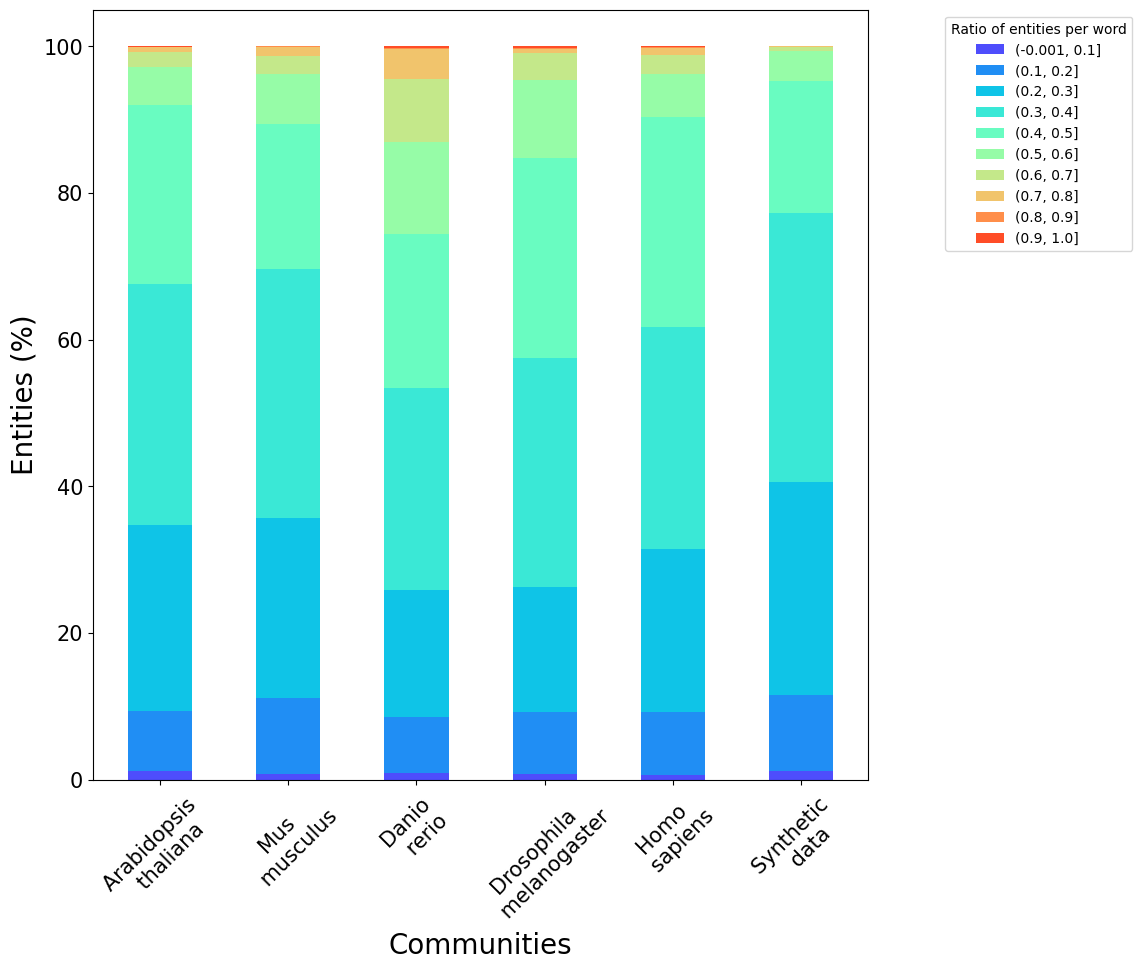

In [111]:
from matplotlib import cm

colors = ['mignightblue','darkslateblue','blue','green', 'yellow','orange', 'red', 'darkblue', 'darkgreen', 'darkorange'] 
palette = cm.rainbow(np.linspace(0.1, 0.9, 10))

plt.subplots(figsize = (10,10))
bar_width = 0.5
index = np.arange(len(communities))

data = np.array(data)
bottom = np.zeros(len(communities))

for i in range(len(values)):
    plt.bar(index, data[:, i], bar_width, bottom = bottom, color = palette[i % len(palette)], label = values[i])
    bottom += data[:,i]


plt.xlabel('Communities', fontsize = 20)
plt.ylabel('Entities (%)', fontsize = 20)

#plt.title('Percentage of the ratio of entities in the abstracts per community')
plt.xticks(index, communities, fontsize = 15, rotation = 45)
plt.yticks(fontsize = 15)

plt.legend(title = 'Ratio of entities per word', bbox_to_anchor = (1.35, 1), loc = 'upper right', fontsize = 10)
#plt.tight_layout()
plt.show()

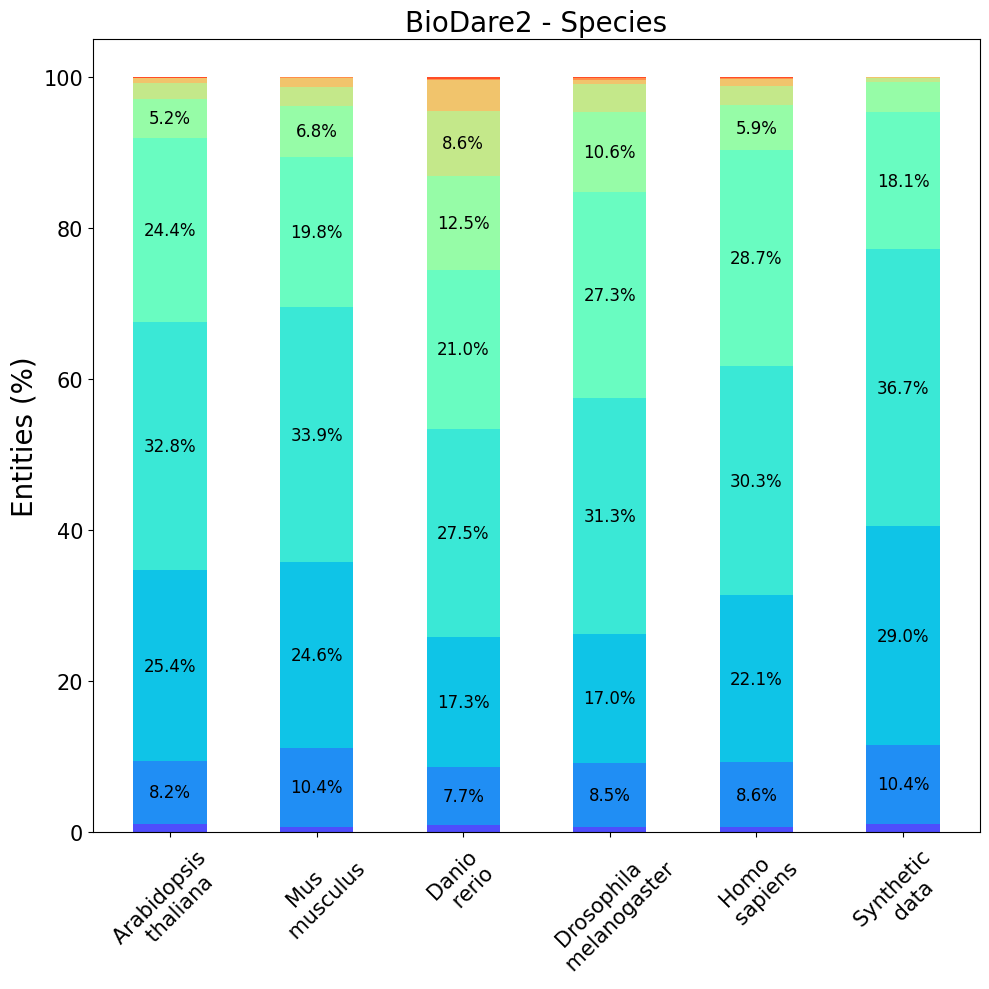

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

palette = cm.rainbow(np.linspace(0.1, 0.9, 10))

plt.figure(figsize=(10, 10))
bar_width = 0.5
index = np.arange(len(communities))

data = np.array(data)
bottom = np.zeros(len(communities))
threshold = 5

for i in range(len(values)):
    bars = plt.bar(
        index,
        data[:, i],
        bar_width,
        bottom=bottom,
        color=palette[i % len(palette)],
        label=values[i]
    )

    # Add percentage labels centered in each segment
    for j, b in enumerate(bars):
        h = b.get_height()
        if h <= threshold:
            continue

        # Only label segments large enough to read (tweak threshold as you like)
        if h < 2:   # "2" means 2 percentage points
            continue

        x = b.get_x() + b.get_width() / 2
        y = bottom[j] + h / 2
        plt.text(
            x, y,
            f"{h:.1f}%",
            ha="center", va="center",
            #rotation = 90,
            fontsize=12,
            #fontweight="bold",
            color="black"
        )

    bottom += data[:, i]

#plt.xlabel("Communities", fontsize=20)
plt.ylabel("Entities (%)", fontsize=20)
plt.xticks(index, communities, fontsize=15, rotation=45)
plt.yticks(fontsize=15)
plt.title("BioDare2 - Species", fontsize = 20)

#plt.legend(
#    title="Ratio of entities per word",
#    bbox_to_anchor=(1.35, 1),
#    loc="upper right",
#    fontsize=10
#)

plt.tight_layout()

plt.savefig("BioDare2_info_density_long_entities_no_legend_20260430.png", dpi=300, bbox_inches="tight")
plt.savefig("BioDare2_info_density_long_entities_no_legend_20260430.eps", dpi=300, bbox_inches="tight", format="eps")
plt.savefig("BioDare2_info_density_long_entities_no_legend_20260430.pdf", dpi=300, bbox_inches="tight")

plt.show()


#### Stats

In [113]:
import numpy as np
from scipy import stats

In [90]:
g_arabidopsis = df_arabidopsis['ratio_entities_per_word'].to_list()
g_mus = df_mus['ratio_entities_per_word'].to_list()
g_danio = df_danio['ratio_entities_per_word'].to_list()
g_drosophila = df_drosophila['ratio_entities_per_word'].to_list()
g_homo = df_homo['ratio_entities_per_word'].to_list()
g_synthetic = df_synthetic['ratio_entities_per_word'].to_list()

In [94]:
groups = [g_arabidopsis, g_mus, g_danio, g_drosophila, g_homo, g_synthetic]

# Remove NaNs (and also drop inf just in case)
clean = []
for g in groups:
    g = np.asarray(g, dtype=float)
    g = g[np.isfinite(g)]          # removes NaN and +/-inf
    clean.append(g)

# Check sizes after cleaning
print([len(g) for g in clean])

F, p = stats.f_oneway(*clean)

print("F =", F, "p =", p)

[7048, 3502, 1793, 565, 2331, 1155]
F = 92.21380448141029 p = 4.655760143723569e-96


In [95]:
names = ["Arabidopsis thaliana", "Mus musculus", "Danio rerio", "Drosophila melanogaster", "Homosapiens", "Synthetic data"]

In [96]:
# Clean NaN/inf and build long-format dataframe
vals_list = []
grp_list  = []

for name, g in zip(names, groups):
    g = np.asarray(g, dtype=float)
    g = g[np.isfinite(g)]  # removes NaN and +/-inf
    vals_list.append(g)
    grp_list.append(np.repeat(name, len(g)))

values = np.concatenate(vals_list)
labels = np.concatenate(grp_list)

df = pd.DataFrame({"value": values, "group": labels})
df.groupby("group").size()

group
Arabidopsis thaliana       7048
Danio rerio                1793
Drosophila melanogaster     565
Homosapiens                2331
Mus musculus               3502
Synthetic data             1155
dtype: int64

In [97]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tuk = pairwise_tukeyhsd(endog=df["value"], groups=df["group"], alpha=0.05)
print(tuk)

                 Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
         group1                  group2         meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------------------
   Arabidopsis thaliana             Danio rerio   0.0601    0.0  0.0504  0.0697   True
   Arabidopsis thaliana Drosophila melanogaster    0.031    0.0   0.015  0.0469   True
   Arabidopsis thaliana             Homosapiens   0.0132 0.0002  0.0045  0.0219   True
   Arabidopsis thaliana            Mus musculus  -0.0023 0.9562 -0.0098  0.0053  False
   Arabidopsis thaliana          Synthetic data  -0.0281    0.0 -0.0397 -0.0166   True
            Danio rerio Drosophila melanogaster  -0.0291    0.0 -0.0467 -0.0115   True
            Danio rerio             Homosapiens  -0.0469    0.0 -0.0583 -0.0354   True
            Danio rerio            Mus musculus  -0.0623    0.0 -0.0729 -0.0518   True
            Danio rerio          Synthetic 